In [ ]:
#Aslihan Berber, Matriculation: 03798114
#Mohammed Yazan Aljleilati, Matriculation: 03728944

#TUM WS 25/26

In [ ]:



!pip install -q -U \
  transformers \
  bitsandbytes \
  accelerate \
  sentence-transformers \
  bertopic \
  hdbscan \
  umap-learn \
  nltk \
  peft \
  trl


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["ACCELERATE_MIXED_PRECISION"] = "no"


In [ ]:
import torch, pandas as pd, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import hdbscan, umap
import matplotlib.pyplot as plt
import os
import pandas as pd
import glob

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cuda


**Loading and Reading Input Mails into JSON File**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import glob
import pandas as pd
#Loading the Emails
def load_emails(path_pattern="/content/drive/My Drive/DAIA_EON/GoldenDataset/*.txt"):
    emails = []
    for f in glob.glob(path_pattern):
        with open(f, "r", encoding="utf8") as fh:
            text = fh.read()
        emails.append({
            "email_id": f.split("/")[-1].replace(".txt", ""),
            "raw_text": text
        })
    return emails

emails = load_emails()

# Converting to DataFrame
df = pd.DataFrame(emails)

print("Loaded", len(df), "emails")
df.head()


Loaded 161 emails


,email_id,raw_text
0,22,Seit Februar haben Sie nicht eine einzige mein...
1,103,"Hallo,\nAnbei meine Vertragsbestätigung.\nMit ..."
2,12,Guten Tag\nEs wurde noch ein Zhlerfoto vom Zäh...
3,41,Hiermit schicke ich die Unterlagen für den Zäh...
4,102,"Hallo EON,\nBitte erstatten Sie auf folgendes ..."


In [ ]:
# Output path for JSON Lines format (.jsonl)
output_path = "/content/drive/My Drive/DAIA_EON/emails_dataset.jsonl"
# Saving as JSONL
df.to_json(
    output_path,
    orient="records",   # each row becomes a separate JSON object
    lines=True,
    force_ascii=False   # keeps the text readable
)
print("Saved JSONL to:", output_path)


Saved JSONL to: /content/drive/My Drive/DAIA_EON/emails_dataset.jsonl


**Topic Detection and Clustering**

In [ ]:
import pandas as pd

# Loading the JSONL
path_jsonl = "/content/drive/My Drive/DAIA_EON/emails_dataset.jsonl"

df = pd.read_json(path_jsonl, lines=True)

df.head()


,email_id,raw_text
0,22,Seit Februar haben Sie nicht eine einzige mein...
1,103,"Hallo,\nAnbei meine Vertragsbestätigung.\nMit ..."
2,12,Guten Tag\nEs wurde noch ein Zhlerfoto vom Zäh...
3,41,Hiermit schicke ich die Unterlagen für den Zäh...
4,102,"Hallo EON,\nBitte erstatten Sie auf folgendes ..."


In [ ]:
# Extracting the list of email texts
documents = df["raw_text"].tolist()

len(documents), documents[0][:300]


(161,
 'Seit Februar haben Sie nicht eine einzige meiner Mails oder Post von meinem Anwalt beantwortet.\nSie haben mir Geld gestohlen und bekommen es jetzt nicht mal auf die Kette, meine Daten aus Ihrem System zu löschen. Auch dies habe ich bereits mehrfach via Portal, Mail und Telefon gefordert, da ich kein')

In [ ]:
from sentence_transformers import SentenceTransformer

# Multilingual model that supports German
model_name = "paraphrase-multilingual-mpnet-base-v2"
embedding_model = SentenceTransformer(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

# Downloading NLTK stopwords once
nltk.download("stopwords")

# 1) German stopwords from NLTK
german_stopwords = set(stopwords.words("german"))

# 2) Extra specific stopwords for German emails
extra_stopwords = {
    "damen", "herren", "sehr", "geehrte", "geehrten", "geehrter",
    "vielen", "dank", "gruß", "grüße", "gruesse",
    "mit", "freundlichen",
    "eon", "energie", "kundenservice", "kundendienst", "kundennummer",
    "guten", "tag", "hallo", "liebe", "lieben"
}

# 3) Combining
all_stopwords = german_stopwords.union(extra_stopwords)

# 4) Vectorizer for BERTopic
vectorizer_model = CountVectorizer(
    stop_words=list(all_stopwords),
    ngram_range=(1, 2),  # 1- and 2-word phrases
    min_df=2             # ignores words that appear only once
)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="german",
    vectorizer_model=vectorizer_model,
    min_topic_size=3,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents)


#topics → list with topic ID for each email (e.g. 0, 1, 2, ...)

#probs → probability distribution over topics for each email


2026-01-28 22:21:57,753 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

2026-01-28 22:21:58,898 - BERTopic - Embedding - Completed ✓
2026-01-28 22:21:58,899 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-28 22:22:07,241 - BERTopic - Dimensionality - Completed ✓
2026-01-28 22:22:07,243 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-28 22:22:07,263 - BERTopic - Cluster - Completed ✓
2026-01-28 22:22:07,267 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-28 22:22:07,300 - BERTopic - Representation - Completed ✓


In [ ]:
import numpy as np

# using fitted vectorizer from BERTopic
cv = topic_model.vectorizer_model

# document-term matrix
X = cv.transform(documents)

# df = how many emails contain each term
doc_freq = np.asarray((X > 0).sum(axis=0)).ravel()

vocab = cv.get_feature_names_out()
df_dict = dict(zip(vocab, doc_freq))

list(df_dict.items())[:20]


[('00', np.int64(2)),
 ('01', np.int64(9)),
 ('01 03', np.int64(2)),
 ('01 09', np.int64(2)),
 ('02', np.int64(5)),
 ('02 2023', np.int64(2)),
 ('03', np.int64(2)),
 ('03 2023', np.int64(2)),
 ('04', np.int64(5)),
 ('04 2023', np.int64(2)),
 ('05', np.int64(5)),
 ('06', np.int64(8)),
 ('06 2023', np.int64(2)),
 ('06 23', np.int64(2)),
 ('07', np.int64(11)),
 ('07 2023', np.int64(8)),
 ('08', np.int64(14)),
 ('08 2023', np.int64(9)),
 ('08 23', np.int64(2)),
 ('09', np.int64(7))]

In [ ]:
# Overview of the topics
topic_info = topic_model.get_topic_info()
topic_info.head(10)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,30,-1_mail_grüßen_bitte_49,"[mail, grüßen, bitte, 49, sowie, 14, herr, zäh...","[Guten Abend liebes Beschwerde- Team,\nleider ..."
1,0,16,0_konto_example_example com_com,"[konto, example, example com, com, dr, wurde, ...","[Sehr geehrte Damen und Herren,\nIch habe für ..."
2,1,15,1_gmbh_zähler_mail_the,"[gmbh, zähler, mail, the, verbrauchsstelle, 20...",[Kunde: \t\t\tWernecke GmbH & Co. OHG und Niem...
3,2,13,2_sende_grüßen_hiermit_bestätigung,"[sende, grüßen, hiermit, bestätigung, ab, jäke...","[Sehr geehrter Damen und Herren, Hiermit sende..."
4,3,13,3_2023_gas_01_on,"[2023, gas, 01, on, neuen, bereits, tarif, bez...","[Sehr geehrte Damen und Herren,\nich nehme Bez..."
5,4,12,4_strom_05_15_49,"[strom, 05, 15, 49, bitte, wende, lautet, lieb...","[Sehr geehrte Damen und Herren,\nwir bitten Si..."
6,5,8,5_aufgrund_rechnung_gerne_berücksichtigen,"[aufgrund, rechnung, gerne, berücksichtigen, f...","[Sehr geehrte Damen und Herren,\naufgrund eine..."
7,6,8,6_zurück_überwiesen_geld_möchte,"[zurück, überwiesen, geld, möchte, 36, möglich...","[Sehr geehrte Damen und Herren,\nleider wurde ..."
8,7,7,7_verträge_gesendet_android mobiltelefon_mail ...,"[verträge, gesendet, android mobiltelefon, mai...","[Guten Tag,\nVertragskonto : 401300594\nZähler..."
9,8,7,8_stromzähler_anhang_rückfragen_bereits,"[stromzähler, anhang, rückfragen, bereits, bit...","[Sehr geehrte Damen und Herren,\n \nzusätzlich..."


**Topic Labeling**

In [ ]:
import pandas as pd
import re

# Words we don't want to see in labels
label_stopwords = {
    # German greeting / boilerplate
    "grüßen", "grußen", "gruss", "gruß", "hiermit", "sende", "bitte",
    "nachricht", "wurde", "neuen", "bereits", "gerne",
    # misc junk / technical
    "android", "mobiltelefon", "example", "gmbh", "co", "kg",
    "the", "or", "on", "com", "mfg", "aufgrund"
}

# Minimum document frequency for label words selected manually
MIN_DF_FOR_LABEL = 5

def clean_candidate(word: str) -> str | None:
    w = word.lower().strip()

    # filtering by document frequency (this removes names)
    if df_dict.get(w, 0) < MIN_DF_FOR_LABEL:
        return None

    # removing tokens with digits
    if any(ch.isdigit() for ch in w):
        return None

    # removing very short tokens
    if len(w) < 3:
        return None

    # filtering by valid characters (letters + optional underscore)
    if not re.match(r"^[a-zäöüß]+(_[a-zäöüß]+)?$", w):
        return None

    if w in label_stopwords:
        return None

    return w

def make_label(topic_id: int) -> str:
    if topic_id == -1:
        return "Sonstige / Ausreißer"

    words_scores = topic_model.get_topic(topic_id)
    clean_words = []
    for w, _ in words_scores:
        cw = clean_candidate(w)
        if cw is None:
            continue
        clean_words.append(cw.replace("_", " "))
        if len(clean_words) == 3:
            break

    if not clean_words:
        return f"Topic {topic_id}"

    return " / ".join(clean_words)

topic_labels = []
for t in topic_info["Topic"]:
    topic_labels.append({"topic_id": t, "topic_label": make_label(t)})

labels_df = pd.DataFrame(topic_labels)
labels_df



,topic_id,topic_label
0,-1,Sonstige / Ausreißer
1,0,konto / vertragsnummer / adresse
2,1,zähler / mail / verbrauchsstelle
3,2,bestätigung / freundlichem
4,3,bezüglich
5,4,strom / lautet
6,5,rechnung / fragen / erhalten
7,6,zurück / überwiesen / geld
8,7,verträge / gesendet
9,8,stromzähler / anhang / rückfragen


In [ ]:
import pandas as pd

# Final chosen topic titles
final_topic_names = {
    -1: "Sonstiges",
     0: "Überweisung / Rückzahlung",
     1: "Stromversorgung",
     2: "Bestätigung",
     3: "Strommeldung",
     4: "Zählerstand / Zählerplatz",
     5: "Vertragspartner / Bestätigung",
     6: "Stromzähler-Anfrage",
     7: "Rechnungsanfrage",
     8: "Vertragsnummer ändern",
     9: "Online-Verträge / Portal",
    10: "Daten & Vertragskonto",
    11: "Portal-Zugang / E-Mail-Probleme",
    12: "Stromvertrag / Grundvertrag",
    13: "Vertrag allgemein",
    14: "Zählerunterlagen / Fehler",
}

# Building labels_df from topic_info + mapping
labels_df = topic_info[["Topic"]].rename(columns={"Topic": "topic_id"})
labels_df["topic_label"] = labels_df["topic_id"].map(final_topic_names)

labels_df



,topic_id,topic_label
0,-1,Sonstiges
1,0,Überweisung / Rückzahlung
2,1,Stromversorgung
3,2,Bestätigung
4,3,Strommeldung
5,4,Zählerstand / Zählerplatz
6,5,Vertragspartner / Bestätigung
7,6,Stromzähler-Anfrage
8,7,Rechnungsanfrage
9,8,Vertragsnummer ändern


In [ ]:
import numpy as np

# Adding cluster info to main dataframe
df["topic_id"] = topics
df["topic_confidence"] = probs.max(axis=1)

# id -> label mapping
id2label = dict(zip(labels_df["topic_id"], labels_df["topic_label"]))

df["topic_label"] = df["topic_id"].map(id2label)


df[["email_id", "topic_id", "topic_label", "topic_confidence"]].head()


,email_id,topic_id,topic_label,topic_confidence
0,22,9,Online-Verträge / Portal,0.193802
1,103,10,Daten & Vertragskonto,1.000000
2,12,1,Stromversorgung,0.610613
3,41,12,Stromvertrag / Grundvertrag,1.000000
4,102,0,Überweisung / Rückzahlung,0.263335


In [ ]:
# Counting the emails per topic
topic_counts = (
    df.groupby("topic_id")
      .size()
      .reset_index(name="count")
      .merge(labels_df, on="topic_id", how="left")
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

topic_counts


,topic_id,count,topic_label
0,-1,30,Sonstiges
1,0,16,Überweisung / Rückzahlung
2,1,15,Stromversorgung
3,2,13,Bestätigung
4,3,13,Strommeldung
5,4,12,Zählerstand / Zählerplatz
6,5,8,Vertragspartner / Bestätigung
7,6,8,Stromzähler-Anfrage
8,7,7,Rechnungsanfrage
9,8,7,Vertragsnummer ändern


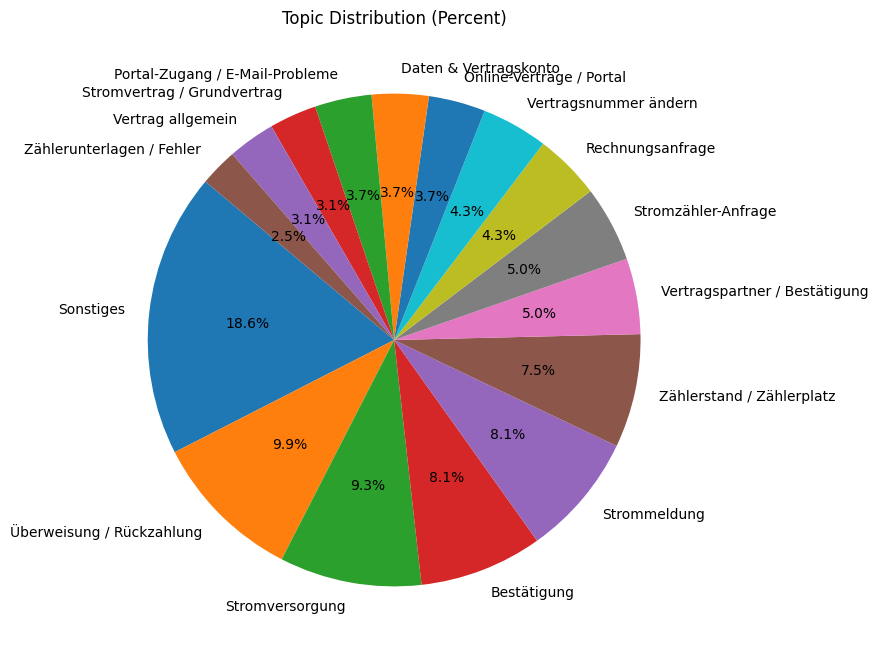

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(
    topic_counts["count"],
    labels=topic_counts["topic_label"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Topic Distribution (Percent)")
plt.show()


Fine Tuning Section

In [ ]:
import os, glob, re
import pandas as pd

pairs_folder = "/content/drive/My Drive/DAIA_EON/GoldenDatasetAnswers"

def parse_pair_file(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    # Normalizing: removing BOM, normalizing newlines
    text = text.replace("\ufeff", "")
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    lines = text.split("\n")

    def find_index(prefixes):
        """Find first line that starts with any of the given prefixes (case-insensitive)."""
        for i, line in enumerate(lines):
            s = line.strip().lower()
            for p in prefixes:
                if s.startswith(p):
                    return i
        return None

    # Allowing several variations, just in case
    idx_input   = find_index(["input", "input:"])
    idx_formal  = find_index(["formal output", "formal output:", "formal ouput:"])
    idx_friendly = find_index([
        "friendly output", "friendly output:", "freindly output:", "friendly ouput:",
        "friendly ouput", "friendly ouput:",
        "freundlich output:"
    ])

    if idx_input is None or idx_formal is None or idx_friendly is None:
        raise ValueError(
            f"Could not find all sections (input/formal/friendly). "
            f"Found indices: input={idx_input}, formal={idx_formal}, friendly={idx_friendly}"
        )

    # Slicing the text blocks between the markers
    input_text = "\n".join(lines[idx_input+1:idx_formal]).strip()
    formal_text = "\n".join(lines[idx_formal+1:idx_friendly]).strip()
    friendly_text = "\n".join(lines[idx_friendly+1:]).strip()

    return {
        "file": os.path.basename(path),
        "input": input_text,
        "formal": formal_text,
        "friendly": friendly_text,
    }

# Re-running the parsing
records = []
for fp in sorted(glob.glob(os.path.join(pairs_folder, "*.txt"))):
    try:
        records.append(parse_pair_file(fp))
    except Exception as e:
        print("ERROR in", fp, "->", e)

df_pairs = pd.DataFrame(records)
print("Parsed files:", len(df_pairs))
df_pairs.head()


Parsed files: 161


,file,input,formal,friendly
0,0.txt,Wie angefordert der Kontoauszug. Abbuchung Eur...,"Sehr geehrte Kundin, sehr geehrter Kunde,\n\n\...","Guten Tag,\n\n\nvielen Dank, dass Sie uns den ..."
1,1.txt,"Hallo liebes Eon Team,\nes geht um die Vertrag...","Sehr geehrter Herr Huhn,\nvielen Dank für Ihre...","Guten Tag Herr Huhn,\ndanke für Ihre Nachricht..."
2,10.txt,">\n> Sehr geehrter Damen und Herren,\n>\n> Wür...","Sehr geehrter Herr Fischer,\nvielen Dank für I...","Guten Tag, Herr Fischer,\nvielen Dank für Ihre..."
3,100.txt,Vertragsnummer 404149058\n \nFam. Zirme/Rogner...,"Sehr geehrte Familie Zirme/Rogner,\nvielen Dan...","Hallo Familie Zirme/Rogner,\nvielen Dank für I..."
4,101.txt,"Sehr geehrte Damen und Herren,\nwie bereits be...","Sehr geehrter Herr Zorbach,\nvielen Dank für I...","Hallo Herr Zorbach,\nvielen Dank für Ihre Nach..."


In [ ]:
import transformers, torch
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)


transformers: 5.0.0
torch: 2.9.0+cu126


In [ ]:
%pip install -q -U bitsandbytes==0.49.0 transformers accelerate peft trl


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

tiny_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
print("Trying to load:", tiny_name)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(tiny_name)
print("TinyLlama tokenizer loaded")

model = AutoModelForCausalLM.from_pretrained(
    tiny_name,
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
print("TinyLlama model loaded")


Trying to load: TinyLlama/TinyLlama-1.1B-Chat-v1.0


`torch_dtype` is deprecated! Use `dtype` instead!


TinyLlama tokenizer loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama model loaded


In [ ]:
import json

# These are the instructions the model learns to follow
FORMAL_INSTR = (
    "Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. "
    "Formuliere eine formelle, klare und höfliche Antwort-E-Mail auf Deutsch."
)

FRIENDLY_INSTR = (
    "Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. "
    "Formuliere eine freundliche und weniger formelle Antwort-E-Mail auf Deutsch."
)

training_records = []

for _, row in df_pairs.iterrows():
    email = (row["input"] or "").strip()
    formal = (row["formal"] or "").strip()
    friendly = (row["friendly"] or "").strip()

    if not email or not formal or not friendly:
        continue

    # formal example
    training_records.append({
        "instruction": FORMAL_INSTR,
        "input": email,
        "output": formal,
    })

    # friendly example
    training_records.append({
        "instruction": FRIENDLY_INSTR,
        "input": email,
        "output": friendly,
    })

print("Total training examples:", len(training_records))
training_records[0]


Total training examples: 322


{'instruction': 'Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. Formuliere eine formelle, klare und höfliche Antwort-E-Mail auf Deutsch.',
 'input': 'Wie angefordert der Kontoauszug. Abbuchung Euro 103,22.\nGesendet mit der Stiffel AG Mail App\n<http://www.t-online.de/service/redir/emailmobilapp_ios_smartphone_footerlink.htm>',
 'output': 'Sehr geehrte Kundin, sehr geehrter Kunde,\n\n\nvielen Dank für Ihre E-Mail und die Bereitstellung der angeforderten Informationen zu Ihrem Kontoauszug.\n\n\nWir bestätigen hiermit den Eingang Ihres Nachweises bezüglich der Zahlung über 103,22 €.\n\n\nDie Unterlagen wurden zur Prüfung an die zuständige Fachabteilung weitergeleitet. Die Bearbeitung und Zuordnung der Zahlung kann einige Werktage in Anspruch nehmen. Sobald die Prüfung abgeschlossen ist, werden wir den Vorgang entsprechend verbuchen.\n\n\nWir bedanken uns für Ihre Mithilfe und stehen Ihnen bei weiteren Fragen jederzeit zur Verfügung.\n\n\nMit freundlichen G

In [ ]:
train_jsonl = "/content/drive/My Drive/DAIA_EON/eon_tinyllama_training_data.jsonl"

with open(train_jsonl, "w", encoding="utf-8") as f:
    for rec in training_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved training data to:", train_jsonl)


Saved training data to: /content/drive/My Drive/DAIA_EON/eon_tinyllama_training_data.jsonl


In [ ]:
from datasets import load_dataset

dataset = load_dataset("json", data_files={"train": train_jsonl})["train"]
print("Total raw examples:", len(dataset))
print(dataset[0])


Generating train split: 0 examples [00:00, ? examples/s]

Total raw examples: 322
{'instruction': 'Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. Formuliere eine formelle, klare und höfliche Antwort-E-Mail auf Deutsch.', 'input': 'Wie angefordert der Kontoauszug. Abbuchung Euro 103,22.\nGesendet mit der Stiffel AG Mail App\n<http://www.t-online.de/service/redir/emailmobilapp_ios_smartphone_footerlink.htm>', 'output': 'Sehr geehrte Kundin, sehr geehrter Kunde,\n\n\nvielen Dank für Ihre E-Mail und die Bereitstellung der angeforderten Informationen zu Ihrem Kontoauszug.\n\n\nWir bestätigen hiermit den Eingang Ihres Nachweises bezüglich der Zahlung über 103,22 €.\n\n\nDie Unterlagen wurden zur Prüfung an die zuständige Fachabteilung weitergeleitet. Die Bearbeitung und Zuordnung der Zahlung kann einige Werktage in Anspruch nehmen. Sobald die Prüfung abgeschlossen ist, werden wir den Vorgang entsprechend verbuchen.\n\n\nWir bedanken uns für Ihre Mithilfe und stehen Ihnen bei weiteren Fragen jederzeit zur Verfügung.\n

In [ ]:
# 80/20 train/validation split
splits = dataset.train_test_split(test_size=0.2, seed=42)
train_ds = splits["train"]
eval_ds  = splits["test"]

len(train_ds), len(eval_ds)


(257, 65)

In [ ]:
def format_example(example):
    system = example["instruction"]
    user   = example["input"]
    answer = example["output"]

    text = (
        f"{system}\n\n"
        f"Kunden-E-Mail:\n{user}\n\n"
        f"Antwort:\n{answer}"
    )
    return {"text": text}

train_ds = train_ds.map(format_example)
eval_ds  = eval_ds.map(format_example)

# keeping only "text" column
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c != "text"])
eval_ds  = eval_ds.remove_columns([c for c in eval_ds.column_names if c != "text"])

train_ds[0]


Map:   0%|          | 0/257 [00:00<?, ? examples/s]

Map:   0%|          | 0/65 [00:00<?, ? examples/s]

{'text': 'Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. Formuliere eine formelle, klare und höfliche Antwort-E-Mail auf Deutsch.\n\nKunden-E-Mail:\nSehr geehrte Damen und Herren,\nich habe aufgrund des Todes meines Vaters den Stromvertrag von ihm übernommen. Diesen habe ich am 21.August 2023 gewechselt. Die neue Vertragsnummer ist 406728910.\nDie Zählernummer allerdings ist gleich geblieben 1APADA91675322.\nWenn ich mich jetzt in mein Vertragskonto online einloggen möchte, wird mir nur der alte Vertrag angezeigt. Dort steht auch, dass dieser alte Vertrag deaktiviert wurde. Den neuen Vertrag kann ich aber leider online nicht sehen.\nWie gehe ich nun vor, dass ich den neuen Vertrag in meinem Benutzerkonto sehen kann?\nMit freunlichen Grüßen\nHenriette Knappe-Gierschner\n\nAntwort:\nSehr geehrte Frau Knappe-Gierschner,\n\nvielen Dank für Ihre E-Mail.\n\nWir haben verstanden, dass in Ihrem Online-Konto nur der alte, deaktivierte Vertrag angezeigt wird und n

In [ ]:
'''
import torch
torch.set_default_dtype(torch.float16)

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
'''

'\nimport torch\ntorch.set_default_dtype(torch.float16)\n\nfrom transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig\nfrom peft import LoraConfig\nfrom trl import SFTTrainer, SFTConfig\n'

In [ ]:
'''
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
'''

'\nmodel_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"\n\nbnb_config = BitsAndBytesConfig(\n    load_in_4bit=True,\n    bnb_4bit_compute_dtype=torch.float16,\n    bnb_4bit_use_double_quant=True,\n    bnb_4bit_quant_type="nf4",\n)\n\ntokenizer = AutoTokenizer.from_pretrained(model_name)\nif tokenizer.pad_token is None:\n    tokenizer.pad_token = tokenizer.eos_token\n\nmodel = AutoModelForCausalLM.from_pretrained(\n    model_name,\n    quantization_config=bnb_config,\n    device_map="auto",\n    torch_dtype=torch.float16,\n)\n'

In [ ]:
'''
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)
'''

'\nlora_config = LoraConfig(\n    r=8,\n    lora_alpha=16,\n    lora_dropout=0.05,\n    bias="none",\n    task_type="CAUSAL_LM",\n    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],\n)\n'

In [ ]:

'''
from trl import SFTConfig

sft_config = SFTConfig(
    output_dir="/content/drive/My Drive/DAIA_EON/tinyllama_eon_qlora",

    # batch handling
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,   # effective batch = 8

    # training length
    max_steps=600,
    warmup_ratio=0.05,

    # stability
    learning_rate=2e-5,
    max_grad_norm=0.3,

    # logging / saving
    logging_steps=25,
    save_steps=300,
    save_total_limit=2,

    # precision
    fp16=False,
    bf16=False,

    # QLoRA optimizer
    optim="paged_adamw_8bit",

    report_to=[],
)

'''

'\nfrom trl import SFTConfig\n\nsft_config = SFTConfig(\n    output_dir="/content/drive/My Drive/DAIA_EON/tinyllama_eon_qlora",\n\n    # batch handling\n    per_device_train_batch_size=1,\n    gradient_accumulation_steps=8,   # effective batch = 8\n\n    # training length\n    max_steps=600,\n    warmup_ratio=0.05,\n\n    # stability\n    learning_rate=2e-5,\n    max_grad_norm=0.3,\n\n    # logging / saving\n    logging_steps=25,\n    save_steps=300,\n    save_total_limit=2,\n\n    # precision\n    fp16=False,\n    bf16=False,\n\n    # QLoRA optimizer\n    optim="paged_adamw_8bit",\n\n    report_to=[],\n)\n\n'

In [ ]:
'''
from trl import SFTTrainer
trainer = SFTTrainer(
    model=model,              # loaded base model
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    peft_config=lora_config,
    args=sft_config,
)

# safety: ensuring no scaler
if hasattr(trainer.accelerator, "scaler"):
    trainer.accelerator.scaler = None

trainer.train()
'''

'\nfrom trl import SFTTrainer\ntrainer = SFTTrainer(\n    model=model,              # loaded base model\n    train_dataset=train_ds,\n    eval_dataset=eval_ds,\n    peft_config=lora_config,\n    args=sft_config,\n)\n\n# safety: ensuring no scaler\nif hasattr(trainer.accelerator, "scaler"):\n    trainer.accelerator.scaler = None\n\ntrainer.train()\n'

In [ ]:
'''
print("Eval samples:", len(eval_ds))
print("Global step:", trainer.state.global_step)
'''

'\nprint("Eval samples:", len(eval_ds))\nprint("Global step:", trainer.state.global_step)\n'

In [ ]:
'''
metrics = trainer.evaluate()
print(metrics)
'''

'\nmetrics = trainer.evaluate()\nprint(metrics)\n'

In [ ]:
'''
train_ds[0]
eval_ds[0]
'''

'\ntrain_ds[0]\neval_ds[0]\n'

In [ ]:
'''
import torch
torch.set_default_dtype(torch.float16)
'''

'\nimport torch\ntorch.set_default_dtype(torch.float16)\n'

In [ ]:
'''
# Checking for empty / tiny examples
lengths = [len(tokenizer(x["text"]).input_ids) for x in eval_ds.select(range(min(50, len(eval_ds))))]
print("min/max token length:", min(lengths), max(lengths))
print("num very short (<20):", sum(l < 20 for l in lengths))
'''

'\n# Checking for empty / tiny examples\nlengths = [len(tokenizer(x["text"]).input_ids) for x in eval_ds.select(range(min(50, len(eval_ds))))]\nprint("min/max token length:", min(lengths), max(lengths))\nprint("num very short (<20):", sum(l < 20 for l in lengths))\n'

In [ ]:
#eval_ds[0]["text"][:500]

In [ ]:
'''
print(len(train_ds))
print(len(eval_ds))
'''

'\nprint(len(train_ds))\nprint(len(eval_ds))\n'

In [ ]:
'''
import torch

def check_nans_in_lora(m):
    nan_params = []
    inf_params = []
    for n, p in m.named_parameters():
        if "lora_" in n:
            if torch.isnan(p).any():
                nan_params.append(n)
            if torch.isinf(p).any():
                inf_params.append(n)
    print("LoRA params with NaNs:", len(nan_params))
    print("LoRA params with Infs:", len(inf_params))
    if nan_params: print("Example NaN:", nan_params[0])
    if inf_params: print("Example Inf:", inf_params[0])

check_nans_in_lora(trainer.model)
'''

'\nimport torch\n\ndef check_nans_in_lora(m):\n    nan_params = []\n    inf_params = []\n    for n, p in m.named_parameters():\n        if "lora_" in n:\n            if torch.isnan(p).any():\n                nan_params.append(n)\n            if torch.isinf(p).any():\n                inf_params.append(n)\n    print("LoRA params with NaNs:", len(nan_params))\n    print("LoRA params with Infs:", len(inf_params))\n    if nan_params: print("Example NaN:", nan_params[0])\n    if inf_params: print("Example Inf:", inf_params[0])\n\ncheck_nans_in_lora(trainer.model)\n'

**Testing Our Model (Generation Tests)**

In [ ]:
'''
import os, re, torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

base_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
lora_root = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_qlora"
out_dir   = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_merged"

# Picking the latest checkpoint
if not os.path.exists(lora_root):
    raise FileNotFoundError(f"LoRA root not found: {lora_root}")

ckpts = [
    os.path.join(lora_root, d)
    for d in os.listdir(lora_root)
    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(lora_root, d))
]
if not ckpts:
    raise RuntimeError(f"No checkpoints found in {lora_root}")

def step_num(p: str) -> int:
    m = re.search(r"checkpoint-(\d+)", os.path.basename(p))
    return int(m.group(1)) if m else -1

ckpt = max(ckpts, key=step_num)
print("Using checkpoint:", ckpt)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_name, use_fast=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load base model (fp16)
base = AutoModelForCausalLM.from_pretrained(
    base_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

# Loading LoRA + merge
model_ft = PeftModel.from_pretrained(base, ckpt)
model_ft = model_ft.merge_and_unload()

# Setting config ids
model_ft.config.pad_token_id = tokenizer.pad_token_id
model_ft.config.eos_token_id = tokenizer.eos_token_id

model_ft.eval()

# Saving merged model
os.makedirs(out_dir, exist_ok=True)
model_ft.save_pretrained(out_dir, safe_serialization=True)
tokenizer.save_pretrained(out_dir)

print("Saved merged model to:", out_dir)
print("Device:", next(model_ft.parameters()).device)
'''

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3607151502.py:23: SyntaxWarning: invalid escape sequence '\d'
  m = re.search(r"checkpoint-(\d+)", os.path.basename(p))


'\nimport os, re, torch\nfrom transformers import AutoTokenizer, AutoModelForCausalLM\nfrom peft import PeftModel\n\nbase_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"\nlora_root = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_qlora"\nout_dir   = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_merged"\n\n# Picking the latest checkpoint\nif not os.path.exists(lora_root):\n    raise FileNotFoundError(f"LoRA root not found: {lora_root}")\n\nckpts = [\n    os.path.join(lora_root, d)\n    for d in os.listdir(lora_root)\n    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(lora_root, d))\n]\nif not ckpts:\n    raise RuntimeError(f"No checkpoints found in {lora_root}")\n\ndef step_num(p: str) -> int:\n    m = re.search(r"checkpoint-(\\d+)", os.path.basename(p))\n    return int(m.group(1)) if m else -1\n\nckpt = max(ckpts, key=step_num)\nprint("Using checkpoint:", ckpt)\n\n# Tokenizer\ntokenizer = AutoTokenizer.from_pretrained(base_name, use_fast=False)\nif tokenizer.pad_token is 

In [ ]:
import re
import torch

# 1) Topic (BERTopic)
def get_topic_label(email_text: str) -> str:
    # topic_model + final_topic_names exist/come from our BERTopic section
    t_id, _ = topic_model.transform([email_text])
    t_id = int(t_id[0])
    return final_topic_names.get(t_id, "Sonstiges")

# 2) Short summary (rule-based)
def short_summary(email_text: str, max_sentences: int = 2) -> str:
    text = email_text.strip()

    drop_lines = []
    for line in text.splitlines():
        l = line.strip()
        if not l:
            continue
        if re.match(r"^(hallo|guten tag|sehr geehrte|liebe|freundliche grüße|mit freundlichen grüßen)", l.lower()):
            continue
        drop_lines.append(l)

    clean = " ".join(drop_lines)

    sents = re.split(r"(?<=[\.\!\?])\s+", clean)
    sents = [s.strip() for s in sents if s.strip()]
    return " ".join(sents[:max_sentences]) if sents else clean[:220]

# 3) Reply generation
@torch.no_grad()
def generate_reply(email_text: str, tone: str = "formal", max_new_tokens: int = 220):

    tone = tone.lower().strip()

    if tone == "formal":
        instr = (
            FORMAL_INSTR + "\n"
            "Stilregeln:\n"
            "- Sehr formell und sachlich\n"
            "- Höfliche Distanz (Sie-Form)\n"
            "- Keine lockeren Formulierungen\n"
            "- Klassische Grußformel\n"
        )
        tone_tag = "TON: FORMELL"
    else:
        instr = (
            FRIENDLY_INSTR + "\n"
            "Stilregeln:\n"
            "- Freundlich, empathisch, aber professionell\n"
            "- Einfachere Sprache\n"
            "- Kürzere Sätze\n"
            "- Etwas wärmerer Ton\n"
        )
        tone_tag = "TON: FREUNDLICH"

    safety = (
        "WICHTIG (Compliance-Regeln):\n"
        "1) Antworte ausschließlich auf Basis der Kunden-E-Mail.\n"
        "2) Erfinde KEINE neuen Fakten: keine Nummern, Beträge, Zählerstände, Daten/Zeiträume, Orte/Adressen, Telefon/E-Mail.\n"
        "3) Wenn du Zahlen oder Daten erwähnst, dann NUR wenn sie in der Kunden-E-Mail stehen – und dann GENAU unverändert (keine Rundung, keine Umformatierung, keine zusätzlichen Ziffern).\n"
        "4) Wenn du dir bei einer Zahl/einem Datum nicht sicher bist: NICHT verwenden, sondern nachfragen.\n"
        "5) Behaupte niemals, dass bereits gezahlt/überwiesen wurde, außer der Kunde schreibt das explizit.\n"
        "6) Keine frei erfundenen Zeitangaben (z.B. 'am 22.02.2022', 'seit 2019') – nur wenn exakt so im Text.\n"
        "7) Wenn Infos fehlen, stelle 2–4 konkrete Rückfragen.\n"
    )

    prompt = (
        f"{instr}\n"
        f"{tone_tag}\n\n"
        f"{safety}\n"
        f"Kunden-E-Mail:\n{email_text}\n\n"
        f"Antwort:\n"
    )


    global model_ft, tokenizer

    if "model_ft" not in globals() or "tokenizer" not in globals():
        from transformers import AutoTokenizer, AutoModelForCausalLM

        MERGED_DIR = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_merged"
        tokenizer = AutoTokenizer.from_pretrained(MERGED_DIR, use_fast=False)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        model_ft = AutoModelForCausalLM.from_pretrained(
            MERGED_DIR,
            torch_dtype=torch.float16,
            device_map="auto",
        )
        model_ft.eval()
        model_ft.config.pad_token_id = tokenizer.pad_token_id
        model_ft.config.eos_token_id = tokenizer.eos_token_id

    model = model_ft
    model.eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.pad_token_id

    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    out = model.generate(
        **inputs,
        do_sample=False,
        num_beams=3,
        repetition_penalty=1.15,
        no_repeat_ngram_size=4,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )

    text = tokenizer.decode(out[0], skip_special_tokens=True)
    reply = text.split("Antwort:", 1)[1].strip() if "Antwort:" in text else text.strip()

    # cleaning duplicate signatures if model repeats them
    reply = re.sub(
        r"(\nMit freundlichen Grüßen.*?E\.ON Kundenservice)\s*\1",
        r"\1",
        reply,
        flags=re.DOTALL
    )

    # enforcing E.ON signature once
    if "E.ON Kundenservice" not in reply:
        reply = reply.rstrip() + "\n\nMit freundlichen Grüßen\n[Ihr Name]\nE.ON Kundenservice"

    return reply

# 4) Combined output
def generate_with_topic_summary(email_text: str):
    topic = get_topic_label(email_text)
    summ  = short_summary(email_text)

    formal = generate_reply(email_text, "formal")
    friendly = generate_reply(email_text, "friendly")

    print("THEMA:", topic)
    print("KURZBESCHREIBUNG:", summ)
    print("\n" + "="*80)
    print("FORMAL:\n", formal)
    print("\n" + "="*80)
    print("FRIENDLY:\n", friendly)


In [ ]:
#trial email (a new email that was not used in training)
generate_with_topic_summary(email_text = """Hallo.
Ich entschuldige mich für die entstandenen Schulden und möchte hiermit eine Abwendungsvereinbarung mit ihnen treffen.
Leider konnte ich die Summe nicht direkt zahlen. Die erste Rate in Höhe von 49,57€ werde ich so schnell wie möglich überweisen.
Kundenummer:3657872389
Freundliche Grüße Stella Benner""")



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-28 22:22:22,812 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-28 22:22:26,028 - BERTopic - Dimensionality - Completed ✓
2026-01-28 22:22:26,029 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-28 22:22:26,031 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-28 22:22:26,033 - BERTopic - Probabilities - Completed ✓
2026-01-28 22:22:26,033 - BERTopic - Cluster - Completed ✓


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

THEMA: Stromzähler-Anfrage
KURZBESCHREIBUNG: Ich entschuldige mich für die entstandenen Schulden und möchte hiermit eine Abwendungsvereinbarung mit ihnen treffen. Leider konnte ich die Summe nicht direkt zahlen.

FORMAL:
 Sehr geehrte Frau Benner,
vielen Dank für Ihre Nachricht.
Wir verstehen Ihre Situation sehr gut.
Sobald wir Ihre Zahlung erhalten haben, werden wir Ihnen schnellstmöglich die Vertragsabschlüsse prüfen und Ihre Rückfragen beantworten.
Mit freundlichen Grüßen
[Ihr Name]
E.ON Kundenservice

FRIENDLY:
 Sehr geehrte Frau Benner,
vielen Dank für Ihre Nachricht.
Wir haben Ihre Anfrage erhalten und prüfen die Informationen.
Sobald wir Ihre Zahlung erhalten haben, werden wir Ihnen schnellstmöglich die Vertragsbedingungen übermitteln.
Mit freundlichen Grüßen
[Ihr Name]
E.ON Kundenservice


In [ ]:
import random
import pandas as pd

# Extracting just the customer email from the stored training-style text
def extract_customer_email(full_text: str) -> str:
    start_key = "Kunden-E-Mail:\n"
    end_key = "\n\nAntwort:"
    if start_key in full_text and end_key in full_text:
        return full_text.split(start_key, 1)[1].split(end_key, 1)[0].strip()
    return full_text.strip()


def generate_pack(email_text: str):

    topic = get_topic_label(email_text)
    summ  = short_summary(email_text)

    formal = generate_reply(email_text, "formal")
    friendly = generate_reply(email_text, "friendly")

    return topic, summ, formal, friendly

# sample 10 eval examples (never used in training)
N = 10
random.seed(42)

# Safety in case eval_ds is empty
if len(eval_ds) == 0:
    raise ValueError("eval_ds is empty. Check your dataset split / loading.")

idxs = random.sample(range(len(eval_ds)), k=min(N, len(eval_ds)))
print("Eval indices sampled:", idxs)

rows = []
for i, idx in enumerate(idxs, 1):
    full_text = eval_ds[idx]["text"]
    email = extract_customer_email(full_text)

    topic, summ, formal, friendly = generate_pack(email)

    rows.append({
        "eval_index": idx,
        "topic": topic,
        "summary": summ,
        "customer_email": email,
        "formal_output": formal,
        "friendly_output": friendly,
    })

    print("\n" + "="*90)
    print(f"[{i}/{len(idxs)}] eval_index={idx}")
    print("THEMA:", topic)
    print("KURZBESCHREIBUNG:", summ)
    print("- CUSTOMER EMAIL:\n", email[:1200])  # first ~1200 chars
    print("\n- FORMAL OUTPUT:\n", formal[:1200])
    print("\n- FRIENDLY OUTPUT:\n", friendly[:1200])

# putting into a DataFrame for easy review
df_gen = pd.DataFrame(rows)
df_gen


Eval indices sampled: [14, 3, 47, 17, 15, 64, 8, 62, 6, 43]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-28 22:22:38,534 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-28 22:22:38,543 - BERTopic - Dimensionality - Completed ✓
2026-01-28 22:22:38,543 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-28 22:22:38,545 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-28 22:22:38,547 - BERTopic - Probabilities - Completed ✓
2026-01-28 22:22:38,547 - BERTopic - Cluster - Completed ✓



[1/10] eval_index=14
THEMA: Sonstiges
KURZBESCHREIBUNG: Gerne höre ich von Ihnen Viele Grüße Petros Bonbach Gesendet von Naser Hande KGaA Mail auf Android
- CUSTOMER EMAIL:
 Sehr geehrte Damen und Herren, Da wir durch einen Wasserschadens einen bedingten Mehrverbrauch der Trocknungsgeräten hatten., bitte ich Sie bei den nächsten Abschlagszahlungen dies nicht zu berücksichtigen. Der Betrag wird mir von der Versicherung erstattet. 
Gerne höre ich von Ihnen Viele Grüße Petros Bonbach 
Gesendet von Naser Hande KGaA Mail auf Android

- FORMAL OUTPUT:
 Hallo Herr Bonbach,
vielen Dank für Ihre Nachricht.
Wir haben Ihr Anliegen erhalten und prüfen unsere Daten.
Mit freundlichen Grüßen
[Ihr Name]
E.ON Kundenservice

- FRIENDLY OUTPUT:
 Hallo Herr Bonbach,
vielen Dank für Ihre Nachricht.
Wir haben Ihr Anliegen erhalten und prüfen die Daten.
Sobald wir die Informationen haben, werden wir Ihnen schnellstmöglich entsprechende Änderungen vornehmen.
Mit freundlichen Grüßen
[Ihr Name]
E.ON Kundenserv

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...


[9/10] eval_index=6
THEMA: Online-Verträge / Portal
KURZBESCHREIBUNG: ich widerrufe hiermit meine Einwilligung in die Verarbeitung meiner personenbezogenen Daten. Ich fordere Sie darüber hinaus auf, die von Ihnen zu meiner Person gespeicherten personenbezogenen Daten zu löschen und mir anschließend die Löschung unverzüglich zu bestätigen.
- CUSTOMER EMAIL:
 Sehr geehrte Damen und Herren,
ich widerrufe hiermit meine Einwilligung in die Verarbeitung meiner
personenbezogenen Daten. Ich fordere Sie darüber hinaus auf, die von Ihnen
zu meiner Person gespeicherten personenbezogenen Daten zu löschen und mir
anschließend die Löschung unverzüglich zu bestätigen.
Sollten Gründe gegen die Löschung meiner personenbezogenen Daten sprechen,
bitte ich um Angaben der jeweiligen gesetzlichen Grundlage.
Mit freundlichen Grüßen
Manuel Krein

- FORMAL OUTPUT:
 Hallo Herr Krein,
vielen Dank für Ihre Nachricht.
Wir haben Ihre Rückfrage bezüglich Ihrer Einwilligung zur Verarbeitung Ihrer persönlichen Daten 

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-28 22:24:02,915 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-28 22:24:02,923 - BERTopic - Dimensionality - Completed ✓
2026-01-28 22:24:02,924 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-28 22:24:02,925 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-28 22:24:02,927 - BERTopic - Probabilities - Completed ✓
2026-01-28 22:24:02,928 - BERTopic - Cluster - Completed ✓



[10/10] eval_index=43
THEMA: Sonstiges
KURZBESCHREIBUNG: OR-0001239759 Kunde: Gertraude Wagenknecht-Speer Zähler: 486498046387 Produktwechsel anbei das Formular unterschrieben zurück. Bitte um Kenntnisnahme.
- CUSTOMER EMAIL:
 OR-0001239759
Kunde: Gertraude Wagenknecht-Speer
Zähler: 486498046387
Produktwechsel
Sehr geehrte Damen und Herren,
anbei das Formular unterschrieben zurück.
Bitte um Kenntnisnahme.
Mit freundlichen Grüßen
Gertraude Wagenknecht-Speer
Diese Nachricht wurde von meinem Android Mobiltelefon mit [WEB.DE][1] Mail gesendet.
[1]: http://WEB.DE

- FORMAL OUTPUT:
 Hallo Gertraud,
vielen Dank für Ihre Nachricht.
Wir haben Ihre Zählernummer und den Produktwechsel Ihres Kunden in unserem System aufgenommen.
Sobald wir die Überprüfung abgeschlossen haben, werden wir Ihnen schnellstmöglich mitteilen, ob der Wechsel erfolgreich war.
Viele Grüße
[E.ON Kundenservice]

- FRIENDLY OUTPUT:
 Hallo Gertraud,
vielen Dank für Ihre Nachricht.
Wir haben Ihre Zählernummer und den Produktwe

,eval_index,topic,summary,customer_email,formal_output,friendly_output
0,14,Sonstiges,Gerne höre ich von Ihnen Viele Grüße Petros Bo...,"Sehr geehrte Damen und Herren, Da wir durch ei...","Hallo Herr Bonbach,\nvielen Dank für Ihre Nach...","Hallo Herr Bonbach,\nvielen Dank für Ihre Nach..."
1,3,Sonstiges,"wie in o.g. Telefonat besprochen, warten wir n...","Sehr geehrte Damen und Herren,\nwie in o.g. Te...","Hallo Frau Wähner,\nvielen Diensten Dank für I...","Guten Tag, Frau Wähner,\nvielen dank für Ihre ..."
2,47,Sonstiges,Zähler Wechselprotokoll. Vertragsnummer: 40242...,Zähler Wechselprotokoll.\nVertragsnummer: 4024...,"Sehr geehrter Herr Baum,\nvielen Dank für Ihre...","Sehr geehrter Herr Baum,\nvielen Dank für Ihre..."
3,17,Online-Verträge / Portal,ich bitte Sie mein Kundenkonto samt aller zu m...,"Sehr geehrte Damen und Herren,\nich bitte Sie ...","Hallo Herr Sauer,\n\nvielen Danke für Ihre Nac...","Hallo Herr Sauer,\nvielen Danks für Ihre Nachr..."
4,15,Sonstiges,Wie angefordert der Kontoauszug. Abbuchung Eur...,Wie angefordert der Kontoauszug. Abbuchung Eur...,"Sehr geehrte Damen und Herren,\nvielen Dank fü...","Sehr geehrte Damen und Herren,\nvielen Dank fü..."
5,64,Sonstiges,"Betreuungsbüro ""Schmidtke KG"" L. Jäntsch _____...","Betreuungsbüro ""Schmidtke KG"" L. Jäntsch\n____...","Guten Tag, Herr Jobst,\nviele Grüße!\nWir habe...","Hallo Herr Oderwald,\ndanke für Ihre Nachricht..."
6,8,Sonstiges,Durch einen Fehler ihrerseits wird mir seit Fe...,Durch einen Fehler ihrerseits wird mir seit Fe...,"Sehr geehrte Frau Christl Koch,\nvielen Dank f...","Sehr geehrte Frau Christl Koch,\nvielen Dank f..."
7,62,Sonstiges,wir sind umgezogen: Grundstücksges. Mudering 4...,"Sehr geehrte Damen und Herren,\n \nwir sind um...","Hallo Herr Albers,\n\nvielen Dank für Ihre Nac...","Hallo Herr Albers,\n\nvielen Dank für Ihre Nac..."
8,6,Online-Verträge / Portal,ich widerrufe hiermit meine Einwilligung in di...,"Sehr geehrte Damen und Herren,\nich widerrufe ...","Hallo Herr Krein,\nvielen Dank für Ihre Nachri...","Hallo Herr Krein,\nvielen Dank für Ihre Nachri..."
9,43,Sonstiges,OR-0001239759 Kunde: Gertraude Wagenknecht-Spe...,OR-0001239759\nKunde: Gertraude Wagenknecht-Sp...,"Hallo Gertraud,\nvielen Dank für Ihre Nachrich...","Hallo Gertraud,\nvielen Dank für Ihre Nachrich..."


In [ ]:
out_path = "/content/drive/My Drive/DAIA_EON/generation_eval_10_results.csv"
df_gen.to_csv(out_path, index=False)
print("Saved CSV to:", out_path)


Saved CSV to: /content/drive/My Drive/DAIA_EON/generation_eval_10_results.csv


**Validation Checks**

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Lexical entropy:
  mean: 3.490851310110995
  std : 0.1515178848262257

Semantic similarity:
  mean: 0.6261192
  std : 0.11790265


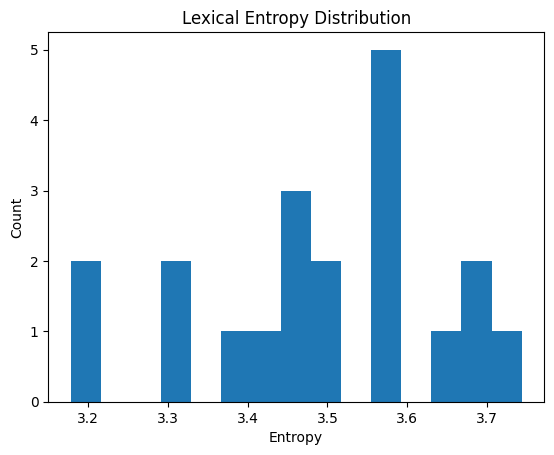

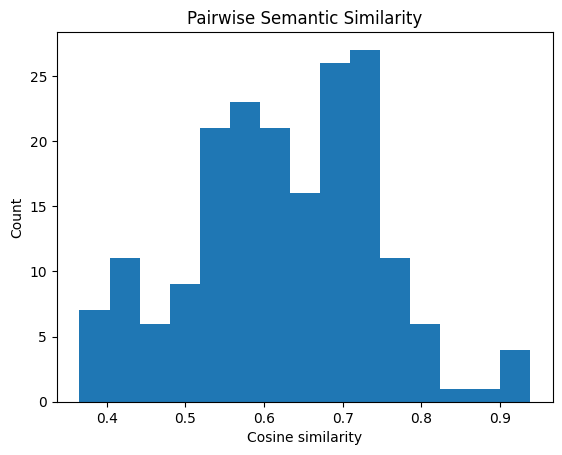

In [ ]:
import numpy as np
import re
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Sentence embedding model (small + fast)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def normalize_text(t):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t.strip()

# Combining formal + friendly
all_outputs = (
    df_gen["formal_output"].tolist()
    + df_gen["friendly_output"].tolist()
)

texts = [normalize_text(t) for t in all_outputs]

# 1) Lexical entropy
def lexical_entropy(text):
    tokens = text.split()
    if not tokens:
        return 0.0
    freqs = np.array(list(Counter(tokens).values()), dtype=float)
    probs = freqs / freqs.sum()
    return -np.sum(probs * np.log(probs + 1e-9))

lex_entropies = [lexical_entropy(t) for t in texts]

# 2) Semantic similarity matrix
embs = embedder.encode(texts, normalize_embeddings=True)
sim_matrix = cosine_similarity(embs)

# removing diagonal
upper_sims = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]

print("Lexical entropy:")
print("  mean:", np.mean(lex_entropies))
print("  std :", np.std(lex_entropies))

print("\nSemantic similarity:")
print("  mean:", np.mean(upper_sims))
print("  std :", np.std(upper_sims))


plt.figure()
plt.hist(lex_entropies, bins=15)
plt.title("Lexical Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(upper_sims, bins=15)
plt.title("Pairwise Semantic Similarity")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.show()


In [ ]:
import re
import pandas as pd

# Extracting candidate "facts"
NUM_PATTERN = re.compile(r"(?<!\w)(?:\d[\d\s\-/\.]{1,}\d|\d)(?!\w)")  # includes 49,57 / 103,22 / 232 671 429 363 etc.
DATE_PATTERN = re.compile(r"\b(?:\d{1,2}[.\-/]\d{1,2}[.\-/]\d{2,4}|\d{4}[.\-/]\d{1,2}[.\-/]\d{1,2})\b")
EMAIL_PATTERN = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
URL_PATTERN = re.compile(r"\b(?:https?://|www\.)\S+\b", re.IGNORECASE)
PHONE_PATTERN = re.compile(r"\b(?:\+?\d{1,3}[\s\-]?)?(?:\(?\d{2,5}\)?[\s\-]?)?\d{3,}[\s\-]?\d{2,}\b")

def normalize_token(s: str) -> str:
    # normalizing spacing to compare "232 671" vs "232671"
    s = re.sub(r"\s+", "", s)
    return s.strip()

def extract_facts(text: str):
    text = str(text)

    nums = {normalize_token(x) for x in NUM_PATTERN.findall(text)}
    dates = {normalize_token(x) for x in DATE_PATTERN.findall(text)}
    emails = {x.lower() for x in EMAIL_PATTERN.findall(text)}
    urls = {x.lower() for x in URL_PATTERN.findall(text)}
    phones = {normalize_token(x) for x in PHONE_PATTERN.findall(text)}

    # removing tiny/meaningless numeric fragments
    nums = {x for x in nums if len(x) >= 3}  # keep 10322, 407982866, 49,57 becomes 49,57 -> normalized "49,57" -> "49,57" -> then remove spaces only, still length>=3

    return {
        "nums": nums,
        "dates": dates,
        "emails": emails,
        "urls": urls,
        "phones": phones,
    }

def hallucination_flags(customer_email: str, reply: str):
    e = extract_facts(customer_email)
    r = extract_facts(reply)

    extra_nums = sorted(list(r["nums"] - e["nums"]))
    extra_dates = sorted(list(r["dates"] - e["dates"]))
    extra_emails = sorted(list(r["emails"] - e["emails"]))
    extra_urls = sorted(list(r["urls"] - e["urls"]))
    extra_phones = sorted(list(r["phones"] - e["phones"]))

    # risk if reply introduces any new "fact-like" strings
    risk = any([
        len(extra_nums) > 0,
        len(extra_dates) > 0,
        len(extra_emails) > 0,
        len(extra_urls) > 0,
        len(extra_phones) > 0,
    ])

    return {
        "hallucination_risk": bool(risk),
        "extra_nums": extra_nums[:20],
        "extra_dates": extra_dates[:20],
        "extra_emails": extra_emails[:20],
        "extra_urls": extra_urls[:20],
        "extra_phones": extra_phones[:20],
    }

# applying to df_gen
df_gen["formal_hallucination"] = df_gen.apply(
    lambda r: hallucination_flags(r["customer_email"], r["formal_output"]), axis=1
)
df_gen["friendly_hallucination"] = df_gen.apply(
    lambda r: hallucination_flags(r["customer_email"], r["friendly_output"]), axis=1
)

df_gen["formal_risk"] = df_gen["formal_hallucination"].apply(lambda x: x["hallucination_risk"])
df_gen["friendly_risk"] = df_gen["friendly_hallucination"].apply(lambda x: x["hallucination_risk"])

print("Formal hallucination rate:", float(df_gen["formal_risk"].mean()))
print("Friendly hallucination rate:", float(df_gen["friendly_risk"].mean()))

# showing the worst cases (flagged)
display_cols = ["eval_index", "topic", "summary", "customer_email", "formal_output", "friendly_output",
                "formal_hallucination", "friendly_hallucination", "formal_risk", "friendly_risk"]

flagged = df_gen[df_gen["formal_risk"] | df_gen["friendly_risk"]][display_cols]
print("\nFlagged rows:", len(flagged), "out of", len(df_gen))

# Showing a compact view first
compact_cols = ["eval_index", "formal_risk", "friendly_risk", "formal_hallucination", "friendly_hallucination"]
display(flagged[compact_cols].head(10))


Formal hallucination rate: 0.0
Friendly hallucination rate: 0.0

Flagged rows: 0 out of 10


,eval_index,formal_risk,friendly_risk,formal_hallucination,friendly_hallucination


**Streamlit WebApp**

In [ ]:
!pip -q install streamlit


In [ ]:
topic_save_dir = "/content/drive/My Drive/DAIA_EON/bertopic_model"
topic_model.save(topic_save_dir)

names_path = "/content/drive/My Drive/DAIA_EON/final_topic_names.txt"
with open(names_path, "w", encoding="utf-8") as f:
    for k, v in final_topic_names.items():
        f.write(f"{k}\t{v}\n")

print("Saved topic model to:", topic_save_dir)
print("Saved topic names to:", names_path)


2026-01-28 22:24:17,024 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved topic model to: /content/drive/My Drive/DAIA_EON/bertopic_model
Saved topic names to: /content/drive/My Drive/DAIA_EON/final_topic_names.txt


In [ ]:
# Trying to empty cache
import torch
torch.cuda.empty_cache()


In [ ]:

%%writefile app.py
import os
import re
import html
import streamlit as st
import streamlit.components.v1 as components
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


# CONFIGURATIONS

MERGED_MODEL_DIR = "/content/drive/My Drive/DAIA_EON/tinyllama_eon_merged"

TOPIC_MODEL_DIR = "/content/drive/My Drive/DAIA_EON/bertopic_model"
TOPIC_NAMES_PATH = "/content/drive/My Drive/DAIA_EON/final_topic_names.txt"

MAX_NEW_TOKENS = 220
TOPIC_MIN_PROB = 0.35


# UI helper: Copy button

def copy_button(text: str, label: str = "Copy"):
    safe = html.escape(text).replace("\n", "\\n").replace("\r", "")
    components.html(
        f"""
        <button style="
            padding: 0.55rem 0.95rem;
            border-radius: 0.7rem;
            border: 1px solid rgba(255,255,255,0.22);
            background: rgba(255,255,255,0.06);
            color: white;
            cursor: pointer;
            font-size: 0.95rem;
        " onclick="navigator.clipboard.writeText('{safe}')">
            {label}
        </button>
        """,
        height=60,
    )


# Text helpers

def strip_invisible(s: str) -> str:
    if s is None:
        return ""
    return (
        s.replace("\u200b", "")
         .replace("\u200c", "")
         .replace("\u200d", "")
         .replace("\ufeff", "")
         .replace("\u00ad", "")
    )

def normalize_spaces(s: str) -> str:
    s = strip_invisible(s)
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def clean_duplicate_signature(reply: str) -> str:
    reply = reply.strip()
    reply = re.sub(
        r"(\nMit freundlichen Grüßen.*?E\.ON Kundenservice)\s*\1",
        r"\1",
        reply,
        flags=re.DOTALL
    )
    if "E.ON Kundenservice" not in reply:
        reply += "\n\nMit freundlichen Grüßen\n[Ihr Name]\nE.ON Kundenservice"
    return reply

def short_summary(email_text: str, max_sentences: int = 2) -> str:
    text = (email_text or "").strip()
    drop_lines = []
    for line in text.splitlines():
        l = line.strip()
        if not l:
            continue
        if re.match(r"^(hallo|guten tag|sehr geehrte|liebe|freundliche grüße|mit freundlichen grüßen)", l.lower()):
            continue
        drop_lines.append(l)
    clean = " ".join(drop_lines)
    sents = re.split(r"(?<=[\.\!\?])\s+", clean)
    sents = [s.strip() for s in sents if s.strip()]
    return " ".join(sents[:max_sentences]) if sents else clean[:220]

def clean_for_topic(email_text: str) -> str:
    text = (email_text or "").strip()
    kept = []
    for line in text.splitlines():
        l = line.strip()
        if not l:
            continue
        if re.match(r"^(hallo|guten tag|sehr geehrte|liebe|freundliche grüße|mit freundlichen grüßen)", l.lower()):
            continue
        kept.append(l)
    return " ".join(kept).strip() if kept else text


# Spliting generated reply into components

CLOSING_START_RE = re.compile(
    r"(?im)^\s*(mit freundlichen grüßen|freundliche grüße|viele grüße|beste grüße|"
    r"mit besten grüßen|hochachtungsvoll|danke und viele grüße)\s*$"
)
GREETING_RE = re.compile(
    r"(?im)^\s*(sehr geehrte|sehr geehrter|guten tag|hallo|liebe|lieber)\b"
)

def split_reply_components(reply: str) -> dict:
    reply = normalize_spaces(reply)

    lines = reply.splitlines()
    while lines and not lines[0].strip():
        lines.pop(0)
    while lines and not lines[-1].strip():
        lines.pop()

    if not lines:
        return {"greeting": "", "main": "", "closing": ""}

    closing_idx = None
    for i, line in enumerate(lines):
        if CLOSING_START_RE.match(line.strip()):
            closing_idx = i
            break

    if closing_idx is not None:
        closing = "\n".join(lines[closing_idx:]).strip()
        body_lines = lines[:closing_idx]
    else:
        closing = ""
        body_lines = lines

    greeting = ""
    main_lines = body_lines[:]

    if body_lines and GREETING_RE.match(body_lines[0].strip()):
        greeting_lines = [body_lines[0].strip()]
        while main_lines and not main_lines[0].strip():
            main_lines.pop(0)
        main_lines = body_lines[1:]
        while main_lines and not main_lines[0].strip():
            main_lines.pop(0)
        greeting = "\n".join(greeting_lines).strip()
    else:
        if len(body_lines[0].strip()) <= 60:
            greeting = body_lines[0].strip()
            main_lines = body_lines[1:]
            while main_lines and not main_lines[0].strip():
                main_lines.pop(0)

    main = "\n".join(main_lines).strip()

    if not closing:
        closing = "Mit freundlichen Grüßen\n[Ihr Name]\nE.ON Kundenservice"

    return {"greeting": greeting, "main": main, "closing": closing}

# No checkboxes: always compile all non-empty parts
def compile_components(parts: dict) -> str:
    chunks = []
    for key in ("greeting", "main", "closing"):
        val = parts.get(key, "").strip()
        if val:
            chunks.append(val)
    return "\n\n".join(chunks).strip()


# Loading Topic Model

@st.cache_resource
def load_topic_tools():
    topic_model = None
    final_topic_names = {}

    if TOPIC_MODEL_DIR and os.path.exists(TOPIC_MODEL_DIR):
        from bertopic import BERTopic
        topic_model = BERTopic.load(TOPIC_MODEL_DIR)

    if TOPIC_NAMES_PATH and os.path.exists(TOPIC_NAMES_PATH):
        with open(TOPIC_NAMES_PATH, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                tid, name = line.split("\t", 1)
                final_topic_names[int(tid)] = name

    return topic_model, final_topic_names

def get_topic_label(email_text: str, topic_model, final_topic_names) -> tuple[str, float | None, int | None]:
    if topic_model is None:
        return "Sonstiges", None, None

    clean_text = clean_for_topic(email_text)
    t_ids, probs = topic_model.transform([clean_text])
    t_id = int(t_ids[0])

    conf = None
    if probs is not None and len(probs) > 0:
        try:
            conf = float(probs[0].max())
        except Exception:
            conf = None

    if conf is not None and conf < TOPIC_MIN_PROB:
        return "Sonstiges", conf, t_id

    label = final_topic_names.get(t_id, f"Topic {t_id}")
    return label, conf, t_id


# Loading saved merged Model

@st.cache_resource
def load_model():
    if not os.path.exists(MERGED_MODEL_DIR):
        raise RuntimeError(f"MERGED_MODEL_DIR not found: {MERGED_MODEL_DIR}")

    tokenizer = AutoTokenizer.from_pretrained(MERGED_MODEL_DIR, use_fast=False)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        MERGED_MODEL_DIR,
        torch_dtype=torch.float16,
        device_map="auto",
    )
    model.eval()

    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id

    return model, tokenizer


# Generation

def build_instruction(tone: str) -> str:
    tone = (tone or "").lower().strip()
    if tone == "formal":
        return (
            "Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. "
            "Formuliere eine formelle, klare und höfliche Antwort-E-Mail auf Deutsch.\n"
            "Stilregeln:\n"
            "- Sehr formell und sachlich\n"
            "- Höfliche Distanz (Sie-Form)\n"
            "- Klassische Grußformel\n"
        )
    return (
        "Du bist ein KI-Assistent, der Mitarbeitende im E.ON-Kundenservice unterstützt. "
        "Formuliere eine freundliche, empathische aber professionelle Antwort-E-Mail auf Deutsch.\n"
        "Stilregeln:\n"
        "- Freundlich, empathisch, aber professionell\n"
        "- Einfachere Sprache\n"
        "- Kürzere Sätze\n"
    )

@torch.no_grad()
def generate_reply(model, tokenizer, email_text: str, tone: str = "formal") -> str:
    instr = build_instruction(tone)

    safety = (
        "WICHTIG:\n"
        "1) Antworte ausschließlich auf Basis der Kunden-E-Mail.\n"
        "2) Erfinde KEINE neuen Fakten: keine Nummern, Beträge, Zählerstände, Daten/Zeiträume, Orte/Adressen, Telefon/E-Mail.\n"
        "3) Wenn Informationen fehlen, stelle 2–4 konkrete Rückfragen.\n"
        "4) Wenn der Kunde noch nicht gezahlt hat oder erst zahlen wird, darf nicht behauptet werden, dass bereits gezahlt/überwiesen wurde.\n"
    )

    prompt = (
        f"{instr}\n\n"
        f"{safety}\n"
        f"Kunden-E-Mail:\n{email_text}\n\n"
        f"Antwort:\n"
    )

    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    out = model.generate(
        **inputs,
        do_sample=False,
        num_beams=3,
        repetition_penalty=1.15,
        no_repeat_ngram_size=4,
        max_new_tokens=MAX_NEW_TOKENS,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )

    text = tokenizer.decode(out[0], skip_special_tokens=True)
    text = strip_invisible(text)

    reply = text.split("Antwort:", 1)[1].strip() if "Antwort:" in text else text.strip()
    reply = normalize_spaces(reply)
    reply = clean_duplicate_signature(reply)
    return reply


# Streamlit UI

st.set_page_config(page_title="E.ON Customer Email Assistant", layout="wide")
st.title("E.ON Customer Email Assistant")

model, tokenizer = load_model()
topic_model, final_topic_names = load_topic_tools()

with st.sidebar:
    st.header("Model")
    st.caption(f"Merged model: {MERGED_MODEL_DIR}")

email_text = st.text_area(
    "Paste customer email here:",
    height=220,
    placeholder="Paste the customer email..."
)

col1, col2 = st.columns(2)
with col1:
    run_formal = st.button("Generate Formal", use_container_width=True)
with col2:
    run_friendly = st.button("Generate Friendly", use_container_width=True)

# Session state storage for component editing
if "formal_parts" not in st.session_state:
    st.session_state.formal_parts = None
if "friendly_parts" not in st.session_state:
    st.session_state.friendly_parts = None
if "active_mode" not in st.session_state:
    st.session_state.active_mode = None  # "formal" or "friendly"

if email_text.strip():
    topic, topic_conf, _ = get_topic_label(email_text, topic_model, final_topic_names)
    summ = short_summary(email_text)

    st.subheader("Topic & Summary")
    st.write(f"**Topic:** {topic}")
    if topic_conf is not None:
        st.caption(f"Topic confidence: {topic_conf:.2f} (threshold: {TOPIC_MIN_PROB:.2f})")
    st.write(f"**Summary:** {summ}")

    # last-clicked-only behavior
    if run_formal:
        formal = generate_reply(model, tokenizer, email_text, "formal")
        st.session_state.formal_parts = split_reply_components(formal)
        st.session_state.friendly_parts = None
        st.session_state.active_mode = "formal"

    if run_friendly:
        friendly = generate_reply(model, tokenizer, email_text, "friendly")
        st.session_state.friendly_parts = split_reply_components(friendly)
        st.session_state.formal_parts = None
        st.session_state.active_mode = "friendly"

    # Rendering only the active mode
    if st.session_state.active_mode == "formal" and st.session_state.formal_parts is not None:
        st.markdown("---")
        st.subheader("Formal: Components")

        parts = st.session_state.formal_parts
        g = st.text_area("Greeting (Formal)", value=parts["greeting"], height=80, key="g_formal")
        m = st.text_area("Main body (Formal)", value=parts["main"], height=220, key="m_formal")
        c = st.text_area("Closing & Signature (Formal)", value=parts["closing"], height=120, key="c_formal")

        st.session_state.formal_parts = {"greeting": g, "main": m, "closing": c}

        compiled = compile_components(st.session_state.formal_parts)
        st.markdown("**Compiled Formal Email**")
        st.code(compiled, language="text")
        copy_button(compiled, "Copy compiled formal email")

    elif st.session_state.active_mode == "friendly" and st.session_state.friendly_parts is not None:
        st.markdown("---")
        st.subheader("Friendly: Components")

        parts = st.session_state.friendly_parts
        g = st.text_area("Greeting (Friendly)", value=parts["greeting"], height=80, key="g_friendly")
        m = st.text_area("Main body (Friendly)", value=parts["main"], height=220, key="m_friendly")
        c = st.text_area("Closing & Signature (Friendly)", value=parts["closing"], height=120, key="c_friendly")

        st.session_state.friendly_parts = {"greeting": g, "main": m, "closing": c}

        compiled = compile_components(st.session_state.friendly_parts)
        st.markdown("**Compiled Friendly Email**")
        st.code(compiled, language="text")
        copy_button(compiled, "Copy compiled friendly email")

    else:
        st.info("Click 'Generate Formal' or 'Generate Friendly' to see components.")

else:
    st.info("Paste a customer email above to begin.")


Overwriting app.py


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(8501)


Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
!pkill -f streamlit || true


^C


In [ ]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 \
  --server.enableCORS false --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &



In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501, height=800)


<IPython.core.display.Javascript object>